In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import skew
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

import matplotlib
matplotlib.rcParams['font.serif'] = "Palatino"
matplotlib.rcParams['font.family'] = "serif"

import sys
sys.path.append("../")
from src.generative_models import get_pt_utility

In [2]:
%load_ext autoreload
%autoreload 2

RNG = np.random.default_rng(2024)
np.set_printoptions(suppress=True)

In [3]:
FONTSIZE_1 = 30
FONTSIZE_2 = 24
FONTSIZE_3 = 20

In [4]:
ev_diff = np.array([-9, -6, -3, -1, 0, 1, 3, 6, 9])
num_trials = np.array([100] * len(ev_diff))

## Old lotteries

In [ ]:
columns = [
    "outcome_a1", "outcome_a2", "outcome_a3",
    "outcome_b1", "outcome_b2", "outcome_b3",
    "ev_a", "ev_b", "ev_diff",
    "var_a", "var_b", "var_diff",
    "loss_a", "loss_b", "loss_diff",
    "skew_a", "skew_b", "skew_diff",
]
old_lotteries = pd.DataFrame(columns=columns)

In [ ]:
for i in tqdm(range(len(ev_diff))):
    counter = 0
    while True:
        # sample random gamble
        loss = RNG.uniform(-100, -1, 2).astype(np.int32)
        middle = RNG.uniform(1, 100, 2).astype(np.int32)
        gain = RNG.uniform(1, 100, 2).astype(np.int32)
        gamble_a = np.sort(np.array([loss[0], middle[0], gain[0]]))[::-1]
        gamble_b = np.sort(np.array([loss[1], middle[1], gain[1]]))[::-1]
        # get ev
        ev_a = np.mean(gamble_a)
        ev_b = np.mean(gamble_b)
        # get loss
        loss_a = np.min(gamble_a)
        loss_b = np.min(gamble_b)
        # get var
        var_a = np.std(gamble_a)
        var_b = np.std(gamble_b)
        # get skewness
        skew_a = np.round(skew(gamble_a), 2)
        skew_b = np.round(skew(gamble_b), 2)

        utility_la = get_pt_utility(
            2.5, 1,
            np.concatenate([gamble_a, gamble_b])
        )
        utility_ra = get_pt_utility(
            1, 0.6,
            np.concatenate([gamble_a, gamble_b])
        )
        # check if two outcomes are the same
        if len(np.concatenate([gamble_a, gamble_b])) == len(np.unique(np.abs(np.concatenate([gamble_a, gamble_b])))):
            # check for ev diff
            if ev_a - ev_b == ev_diff[i]:
                # check if absolute loss_diff is between range
                # if np.abs(loss_a - loss_b) <= 20 and np.abs(loss_a - loss_b) >= 2:
                if np.abs(loss_a - loss_b) <= 15 and np.abs(loss_a - loss_b) >= 2:
                    # check if absolute var_diff is between range
                    # if np.abs(var_a - var_b) <= 20 and np.abs(var_a - var_b) >= 2:
                    if np.abs(var_a - var_b) <= 12 and np.abs(var_a - var_b) >= 2:
                        # check if absolute skew_diff is between range
                        if skew_a - skew_b < 0:
                            # check for loss and var confound
                            if loss_a < loss_b and var_a > var_b:
                                # check if both evs are positive
                                if ev_a > 0 and ev_b > 0:
                                    if i > 1 and i < 7:
                                        if utility_la[0] < utility_la[1] and utility_ra[0] < utility_ra[1]:
                                            gamble = [
                                                {                            
                                                    "outcome_a1": gamble_a[0], "outcome_a2": gamble_a[1],
                                                    "outcome_a3": gamble_a[2], "outcome_b1": gamble_b[0],
                                                    "outcome_b2": gamble_b[1], "outcome_b3": gamble_b[2],
                                                    "ev_a": ev_a, "ev_b": ev_b, "ev_diff": ev_a - ev_b,
                                                    "var_a": var_a, "var_b": var_b, "var_diff": var_a - var_b,
                                                    "loss_a": loss_a, "loss_b": loss_b, "loss_diff": loss_a - loss_b,
                                                    "skew_a": skew_a, "skew_b": skew_b, "skew_diff": skew_a - skew_b
                                                }
                                            ]
                                            old_lotteries = pd.concat([old_lotteries, pd.DataFrame(gamble)], ignore_index=True)
                                            counter += 1
                                            if counter == num_trials[i]:
                                                break
                                    else:
                                        gamble = [
                                                {                            
                                                    "outcome_a1": gamble_a[0], "outcome_a2": gamble_a[1],
                                                    "outcome_a3": gamble_a[2], "outcome_b1": gamble_b[0],
                                                    "outcome_b2": gamble_b[1], "outcome_b3": gamble_b[2],
                                                    "ev_a": ev_a, "ev_b": ev_b, "ev_diff": ev_a - ev_b,
                                                    "var_a": var_a, "var_b": var_b, "var_diff": var_a - var_b,
                                                    "loss_a": loss_a, "loss_b": loss_b, "loss_diff": loss_a - loss_b,
                                                    "skew_a": skew_a, "skew_b": skew_b, "skew_diff": skew_a - skew_b
                                                }
                                            ]
                                        old_lotteries = pd.concat([old_lotteries, pd.DataFrame(gamble)], ignore_index=True)
                                        counter += 1
                                        print(counter)
                                        if counter == num_trials[i]:
                                            break

In [ ]:
# old_lotteries.to_csv("../data/new_approach/lotteries_old_100_7jun.csv", index=False)

## New lotteries

In [ ]:
ev_diff = np.array([-9, -6, -3, -1, 0, 1, 3, 6, 9])
num_trials = np.array([100] * len(ev_diff))

In [ ]:
columns = [
    "outcome_a1", "outcome_a2", "outcome_a3",
    "outcome_b1", "outcome_b2", "outcome_b3",
    "ev_a", "ev_b", "ev_diff",
    "var_a", "var_b", "var_diff",
    "loss_a", "loss_b", "loss_diff",
    "skew_a", "skew_b", "skew_diff",
]
new_lotteries = pd.DataFrame(columns=columns)

In [ ]:
for i in tqdm(range(len(ev_diff))):
    counter = 0
    while True:
        # sample random gamble
        loss = RNG.uniform(-100, -1, 2).astype(np.int32)
        middle = RNG.uniform(1, 100, 2).astype(np.int32)
        gain = RNG.uniform(1, 100, 2).astype(np.int32)
        gamble_a = np.sort(np.array([loss[0], middle[0], gain[0]]))[::-1]
        gamble_b = np.sort(np.array([loss[1], middle[1], gain[1]]))[::-1]
        # get ev
        ev_a = np.mean(gamble_a)
        ev_b = np.mean(gamble_b)
        # get loss
        loss_a = np.min(gamble_a)
        loss_b = np.min(gamble_b)
        # get var
        var_a = np.std(gamble_a)
        var_b = np.std(gamble_b)
        # get skewness
        skew_a = np.round(skew(gamble_a), 2)
        skew_b = np.round(skew(gamble_b), 2)

        utility_la = get_pt_utility(
            2.5, 1,
            np.concatenate([gamble_a, gamble_b])
        )
        utility_ra = get_pt_utility(
            1, 0.6,
            np.concatenate([gamble_a, gamble_b])
        )
        # check if two outcomes are the same
        if len(np.concatenate([gamble_a, gamble_b])) == len(np.unique(np.abs(np.concatenate([gamble_a, gamble_b])))):
            # check for ev diff
            if ev_a - ev_b == ev_diff[i]:
                # check if absolute loss_diff is between range
                if np.abs(loss_a - loss_b) <= 15 and np.abs(loss_a - loss_b) >= 2:
                    # check if absolute var_diff is between range
                    if np.abs(var_a - var_b) <= 12 and np.abs(var_a - var_b) >= 2:
                        # check if absolute skew_diff is between range
                        if skew_a - skew_b < 0:
                            # check for loss and var confound
                            if loss_a < loss_b and var_a < var_b:
                                # check if both evs are positive
                                if ev_a > 0 and ev_b > 0:
                                    if i > 1 and i < 7:
                                        if utility_la[0] < utility_la[1] and utility_ra[0] > utility_ra[1]:
                                            gamble = [
                                                {                            
                                                    "outcome_a1": gamble_a[0], "outcome_a2": gamble_a[1],
                                                    "outcome_a3": gamble_a[2], "outcome_b1": gamble_b[0],
                                                    "outcome_b2": gamble_b[1], "outcome_b3": gamble_b[2],
                                                    "ev_a": ev_a, "ev_b": ev_b, "ev_diff": ev_a - ev_b,
                                                    "var_a": var_a, "var_b": var_b, "var_diff": var_a - var_b,
                                                    "loss_a": loss_a, "loss_b": loss_b, "loss_diff": loss_a - loss_b,
                                                    "skew_a": skew_a, "skew_b": skew_b, "skew_diff": skew_a - skew_b
                                                }
                                            ]
                                            new_lotteries = pd.concat([new_lotteries, pd.DataFrame(gamble)], ignore_index=True)
                                            counter += 1
                                            if counter == num_trials[i]:
                                                break
                                    else:
                                        gamble = [
                                                {                            
                                                    "outcome_a1": gamble_a[0], "outcome_a2": gamble_a[1],
                                                    "outcome_a3": gamble_a[2], "outcome_b1": gamble_b[0],
                                                    "outcome_b2": gamble_b[1], "outcome_b3": gamble_b[2],
                                                    "ev_a": ev_a, "ev_b": ev_b, "ev_diff": ev_a - ev_b,
                                                    "var_a": var_a, "var_b": var_b, "var_diff": var_a - var_b,
                                                    "loss_a": loss_a, "loss_b": loss_b, "loss_diff": loss_a - loss_b,
                                                    "skew_a": skew_a, "skew_b": skew_b, "skew_diff": skew_a - skew_b
                                                }
                                            ]
                                        new_lotteries = pd.concat([new_lotteries, pd.DataFrame(gamble)], ignore_index=True)
                                        counter += 1
                                        print(counter)
                                        if counter == num_trials[i]:
                                            break

In [ ]:
# new_lotteries.to_csv("../data/new_approach/lotteries_new_100_7jun.csv", index=False)

In [85]:
old_lotteries = pd.read_csv("../data/new_approach/lotteries_old_100_7jun.csv")
new_lotteries = pd.read_csv("../data/new_approach/lotteries_new_100_7jun.csv")

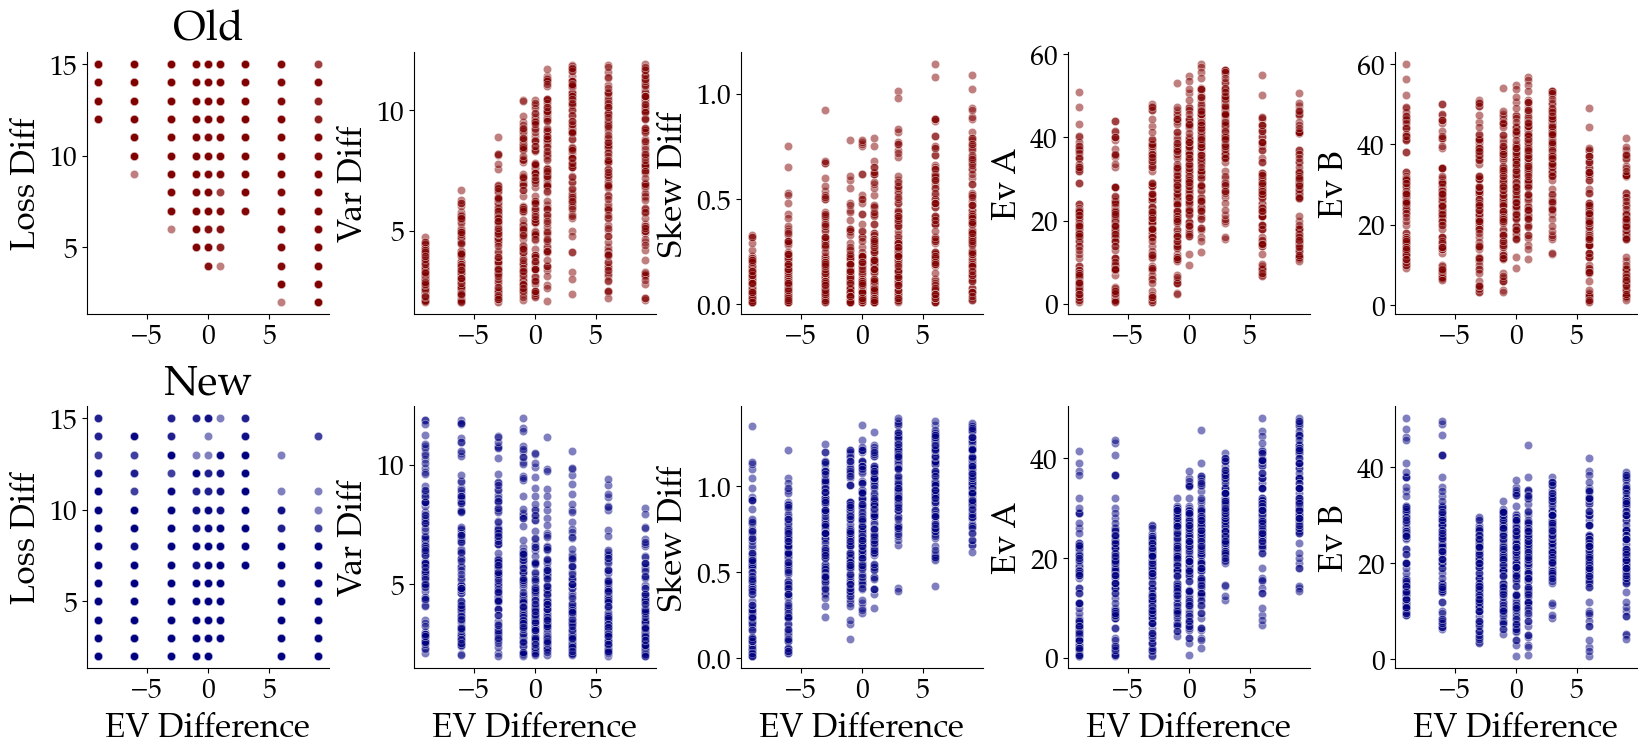

In [86]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8), gridspec_kw={'hspace': 0.35, 'wspace': 0.35})

features = ['loss_diff', 'var_diff', 'skew_diff', 'ev_a', 'ev_b']

for col, feat in enumerate(features):
    # Top row: Old lotteries
    sns.scatterplot(
        data=old_lotteries,
        x='ev_diff',
        y=np.abs(old_lotteries[feat]),
        color='maroon',
        alpha=0.5,
        ax=axes[0, col],
    )
    axes[0, col].set_ylabel(feat.replace('_', ' ').title(), fontsize=FONTSIZE_2)
    axes[0, col].set_xlabel('')
    axes[0, col].tick_params(axis='both', which='major', labelsize=FONTSIZE_3)
    axes[0, col].set_title('Old', fontsize=FONTSIZE_1) if col == 0 else None

    # Bottom row: New lotteries
    sns.scatterplot(
        data=new_lotteries,
        x='ev_diff',
        y=np.abs(new_lotteries[feat]),
        color='navy',
        alpha=0.5,
        ax=axes[1, col],
    )
    axes[1, col].set_ylabel(feat.replace('_', ' ').title(), fontsize=FONTSIZE_2)
    axes[1, col].set_xlabel('EV Difference', fontsize=FONTSIZE_2)
    axes[1, col].tick_params(axis='both', which='major', labelsize=FONTSIZE_3)
    axes[1, col].set_title('New', fontsize=FONTSIZE_1) if col == 0 else None

# Despine all subplots
for row in range(2):
    for col in range(5):
        sns.despine(ax=axes[row, col])


## Nearest Neighbors

In [87]:
features = ['loss_diff', 'var_diff', 'skew_diff']
scaled_features = [f + '_scaled' for f in features]

# Apply hard constraints
def apply_constraints(df):
    df = df[np.abs(df['loss_diff']) >= 5]
    df = df[np.abs(df['var_diff']) <= 8]
    return df.reset_index(drop=True)

df_new = apply_constraints(new_lotteries.copy())
df_old = apply_constraints(old_lotteries.copy())

# Tag source
df_new['source'] = 'new'
df_old['source'] = 'old'
combined = pd.concat([df_new, df_old], ignore_index=True)

# Scale
scaler = StandardScaler()
scaled_data = scaler.fit_transform(combined[features])
for i, f in enumerate(features):
    combined[scaled_features[i]] = scaled_data[:, i]

# Split back
df_new = combined[combined['source'] == 'new'].drop(columns='source').reset_index(drop=True)
df_old = combined[combined['source'] == 'old'].drop(columns='source').reset_index(drop=True)

# EV bins
ev_bins = sorted(combined['ev_diff'].unique())
n_per_bin = 12

sampled_new, sampled_old = [], []

for ev in ev_bins:
    bin_new = df_new[df_new['ev_diff'] == ev]
    bin_old = df_old[df_old['ev_diff'] == ev]

    n_available = min(len(bin_new), len(bin_old), n_per_bin)
    if n_available < n_per_bin:
        print(f"⚠️ Skipping bin {ev} due to insufficient data.")
        continue

    sampled_new.append(bin_new.sample(n=n_per_bin, random_state=42))
    sampled_old.append(bin_old.sample(n=n_per_bin, random_state=42))

# Combine across bins
pooled_new = pd.concat(sampled_new).reset_index(drop=True)
pooled_old = pd.concat(sampled_old).reset_index(drop=True)

# Global matching
dist_matrix = cdist(pooled_new[scaled_features], pooled_old[scaled_features], metric='euclidean')
row_ind, col_ind = linear_sum_assignment(dist_matrix)

matched_new = pooled_new.iloc[row_ind].reset_index(drop=True)
matched_old = pooled_old.iloc[col_ind].reset_index(drop=True)

# Drop scaled features and label
matched_new = matched_new.drop(columns=scaled_features)
matched_old = matched_old.drop(columns=scaled_features)
matched_new['lottery_type'] = 'unconfounded'
matched_old['lottery_type'] = 'confounded'


In [88]:
matched_new['mean_ev'] = matched_new[['ev_a', 'ev_b']].mean(axis=1)
matched_old['mean_ev'] = matched_old[['ev_a', 'ev_b']].mean(axis=1)

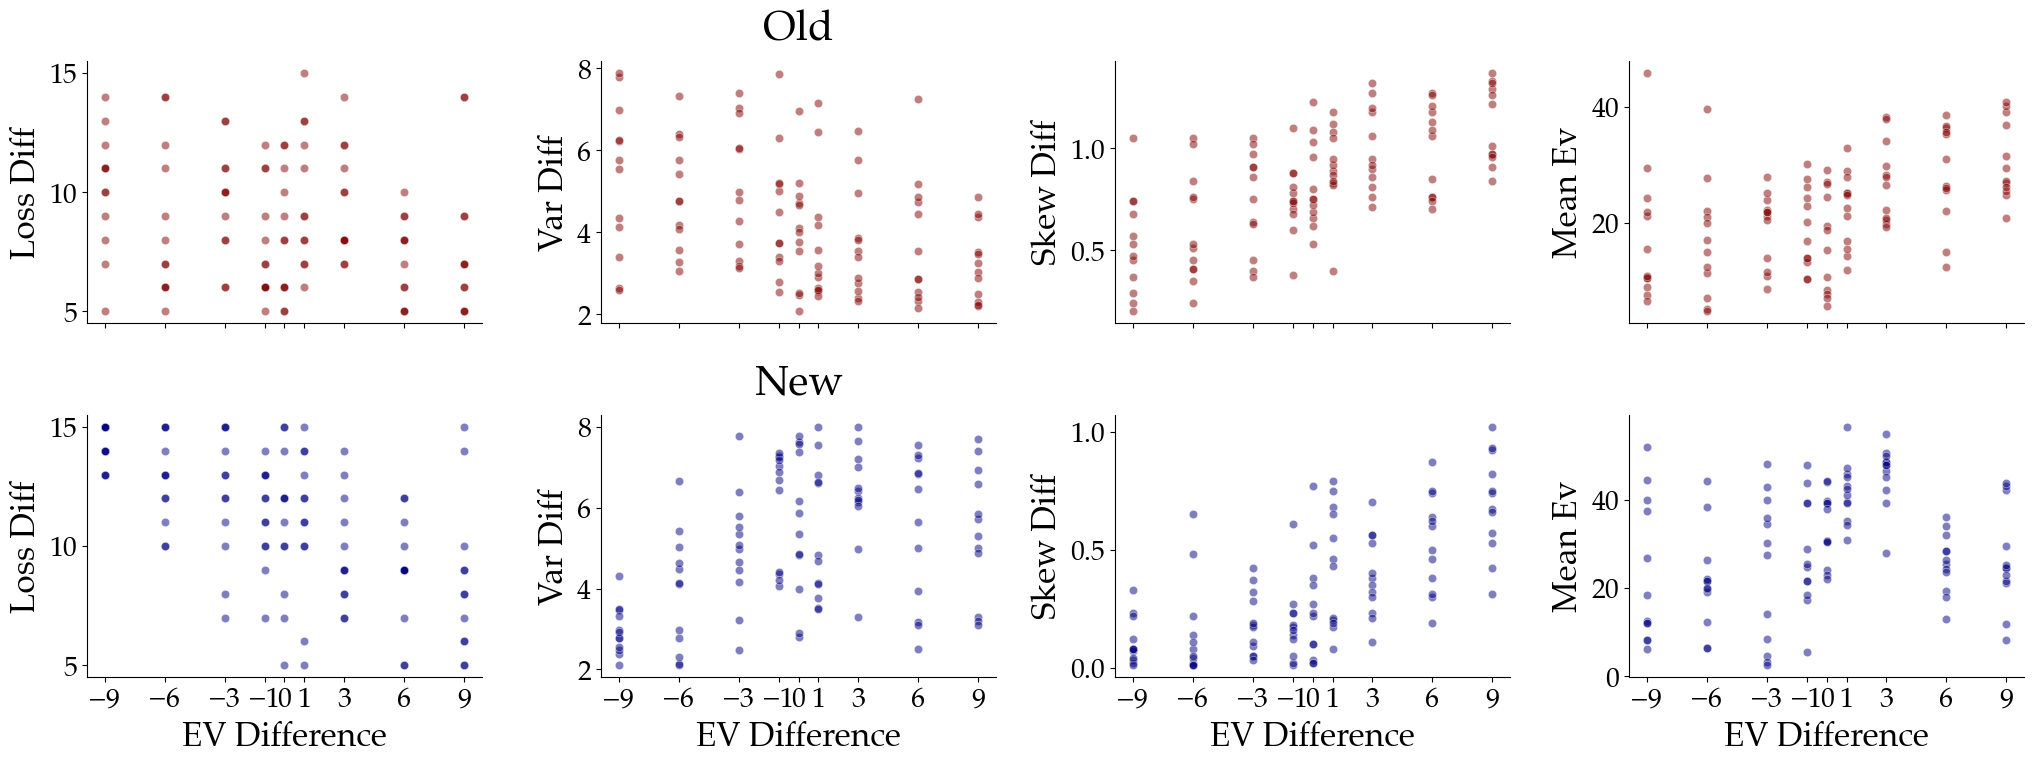

In [89]:
fig, axes = plt.subplots(2, 4, figsize=(25, 8), sharex=True, gridspec_kw={'hspace': 0.35, 'wspace': 0.3})

features = ['loss_diff', 'var_diff', 'skew_diff', 'mean_ev']

for col, feat in enumerate(features):
    # Top row: Old
    sns.scatterplot(
        data=matched_new,
        x='ev_diff',
        y=np.abs(matched_new[feat]),
        color='maroon',
        alpha=0.5,
        ax=axes[0, col],
    )
    axes[0, col].set_ylabel(feat.replace('_', ' ').title(), fontsize=FONTSIZE_2)
    axes[0, col].set_xlabel('')
    if col == 1:
        axes[0, col].set_title('Old', fontsize=FONTSIZE_1, pad=15)
    else:
        axes[0, col].set_title('')
    axes[0, col].tick_params(axis='both', which='major', labelsize=FONTSIZE_3)
    axes[0, col].set_xticks(ev_diff)
    sns.despine(ax=axes[0, col])

    # Bottom row: New
    sns.scatterplot(
        data=matched_old,
        x='ev_diff',
        y=np.abs(matched_old[feat]),
        color='navy',
        alpha=0.5,
        ax=axes[1, col],
    )
    axes[1, col].set_ylabel(feat.replace('_', ' ').title(), fontsize=FONTSIZE_2)
    axes[1, col].set_xlabel('EV Difference', fontsize=FONTSIZE_2)
    if col == 1:
        axes[1, col].set_title('New', fontsize=FONTSIZE_1, pad=15)
    else:
        axes[1, col].set_title('')
    axes[1, col].tick_params(axis='both', which='major', labelsize=FONTSIZE_3)
    axes[1, col].set_xticks(ev_diff)
    sns.despine(ax=axes[1, col])


In [90]:
matched_new['sanity_check'] = False
matched_old['sanity_check'] = False

In [91]:
context_new = matched_new[[
    'outcome_a1', 'outcome_a2', 'outcome_a3',
    'outcome_b1', 'outcome_b2', 'outcome_b3'
]].to_numpy()

context_old = matched_old[[
    'outcome_a1', 'outcome_a2', 'outcome_a3',
    'outcome_b1', 'outcome_b2', 'outcome_b3'
]].to_numpy()

In [92]:
rows_as_tuples = [tuple(row) for row in context_new]
all_unique = len(rows_as_tuples) == len(set(rows_as_tuples))
print("All rows are unique:", all_unique)

All rows are unique: True


In [93]:
rows_as_tuples = [tuple(row) for row in context_old]
all_unique = len(rows_as_tuples) == len(set(rows_as_tuples))
print("All rows are unique:", all_unique)

All rows are unique: True


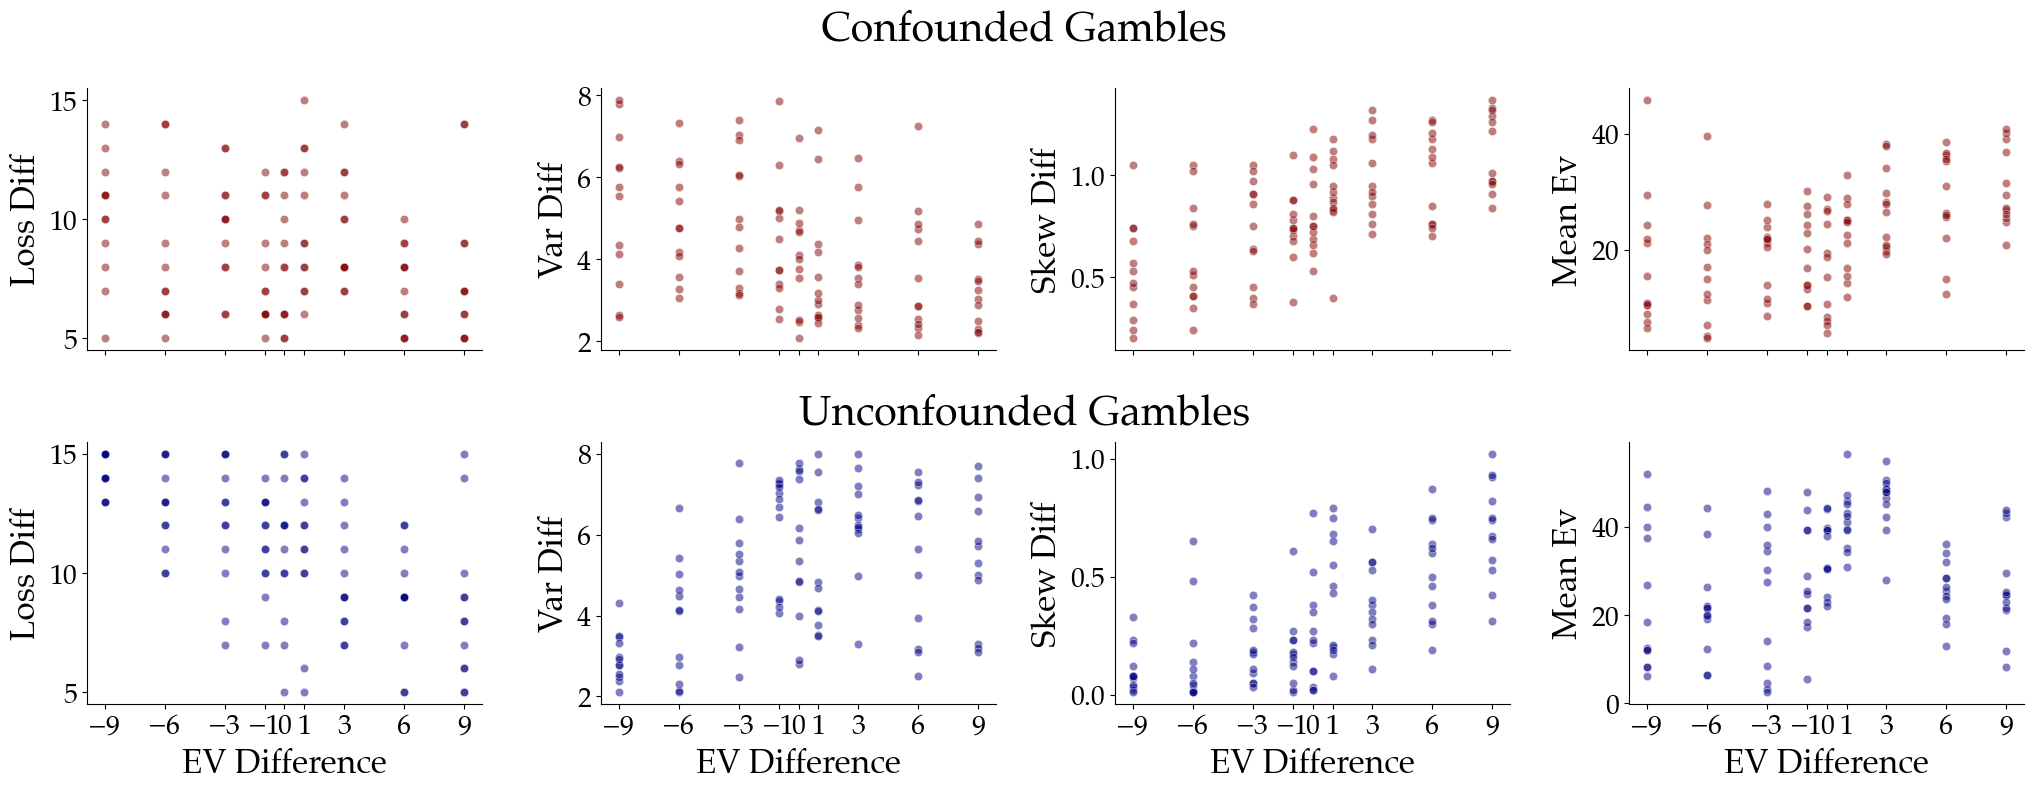

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(2, 4, figsize=(25, 8), sharex=True,
                         gridspec_kw={'hspace': 0.35, 'wspace': 0.3})

features = ['loss_diff', 'var_diff', 'skew_diff', 'mean_ev']

for col, feat in enumerate(features):
    # Top row: Old
    sns.scatterplot(
        data=matched_new,
        x='ev_diff',
        y=np.abs(matched_new[feat]),
        color='maroon',
        alpha=0.5,
        ax=axes[0, col],
    )
    axes[0, col].set_ylabel(feat.replace('_', ' ').title(), fontsize=FONTSIZE_2)
    axes[0, col].set_xlabel('')
    axes[0, col].tick_params(axis='both', which='major', labelsize=FONTSIZE_3)
    axes[0, col].set_xticks(ev_diff)
    sns.despine(ax=axes[0, col])

    # Bottom row: New
    sns.scatterplot(
        data=matched_old,
        x='ev_diff',
        y=np.abs(matched_old[feat]),
        color='navy',
        alpha=0.5,
        ax=axes[1, col],
    )
    axes[1, col].set_ylabel(feat.replace('_', ' ').title(), fontsize=FONTSIZE_2)
    axes[1, col].set_xlabel('EV Difference', fontsize=FONTSIZE_2)
    axes[1, col].tick_params(axis='both', which='major', labelsize=FONTSIZE_3)
    axes[1, col].set_xticks(ev_diff)
    sns.despine(ax=axes[1, col])

# Add centered row titles
fig.text(0.5, 0.94, 'Confounded Gambles', ha='center', fontsize=FONTSIZE_1)
fig.text(0.5, 0.46, 'Unconfounded Gambles', ha='center', fontsize=FONTSIZE_1)

plt.savefig(
    '../plots/gamble_characteristics_01.pdf',
    transparent=True, dpi=600,
    bbox_inches='tight'
)

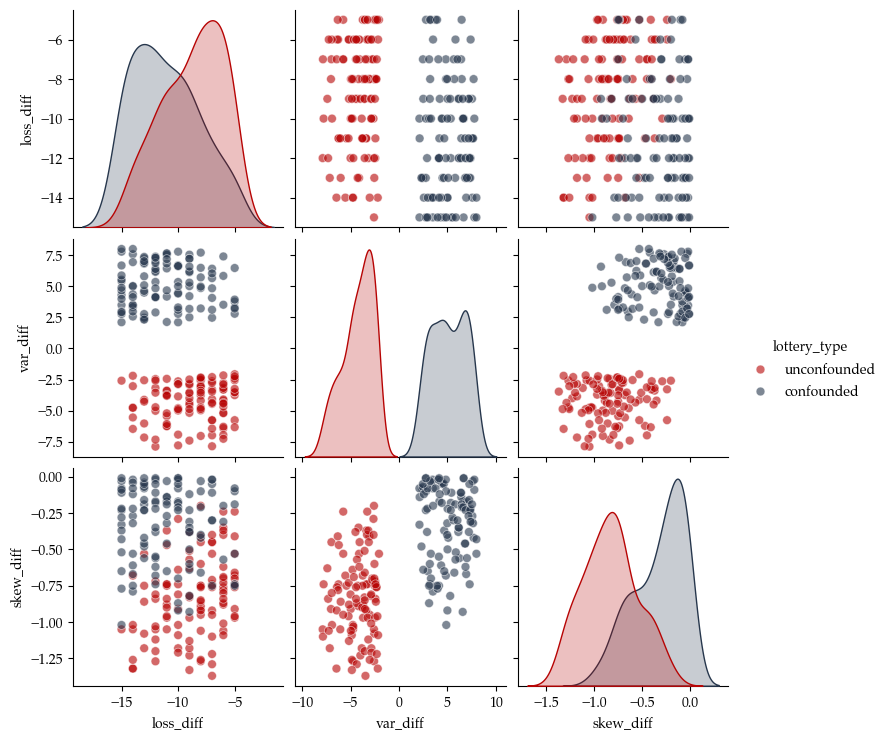

In [95]:
matched_all = pd.concat([matched_new, matched_old], ignore_index=True)

features = ['loss_diff', 'var_diff', 'skew_diff']
sns.pairplot(
    matched_all,
    vars=features,
    hue='lottery_type',
    palette={'unconfounded': '#B70404', 'confounded': '#27374D'},
    plot_kws={'alpha': 0.6, 's': 40},
    diag_kind='kde'
)

plt.savefig(
    '../plots/gamble_characteristics_02.pdf',
    transparent=True, dpi=600,
    bbox_inches='tight'
)


In [96]:
combined = pd.concat([matched_new, matched_old], ignore_index=True)

In [97]:
new_row = pd.DataFrame({
    'outcome_a1': [45], 'outcome_a2': [12], 'outcome_a3': [-30],
    'outcome_b1': [50], 'outcome_b2': [15], 'outcome_b3': [-25],
    'ev_a': [9.0], 'ev_b': [13.33], 'ev_diff': [4.33],
    'var_a': [916.0], 'var_b': [902.22], 'var_diff': [-13.78], 
    'loss_a': [30], 'loss_b': [25], 'loss_diff': [-5],
    'skew_a': [0.2], 'skew_b': [0.3], 'skew_diff': [0.1],
    'lottery_type': ['unconfounded'], 'sanity_check': ['true']
})
combined = pd.concat([combined, new_row], ignore_index=True)

In [98]:
new_row = pd.DataFrame({
    'outcome_a1': [60], 'outcome_a2': [33], 'outcome_a3': [-12],
    'outcome_b1': [66], 'outcome_b2': [40], 'outcome_b3': [-5],
    'ev_a': [27.0], 'ev_b': [33.67], 'ev_diff': [6.67],
    'var_a': [868.67], 'var_b': [822.89], 'var_diff': [-45.78], 
    'loss_a': [12], 'loss_b': [5], 'loss_diff': [-7],
    'skew_a': [-0.1], 'skew_b': [0.1], 'skew_diff': [0.2],
    'lottery_type': ['unconfounded'], 'sanity_check': ['true']
})
combined = pd.concat([combined, new_row], ignore_index=True)

In [99]:
new_row = pd.DataFrame({
    'outcome_a1': [39], 'outcome_a2': [22], 'outcome_a3': [-40],
    'outcome_b1': [47], 'outcome_b2': [30], 'outcome_b3': [-33],
    'ev_a': [7.0], 'ev_b': [14.67], 'ev_diff': [7.67],
    'var_a': [1044.67], 'var_b': [1036.22], 'var_diff': [-8.45], 
    'loss_a': [40], 'loss_b': [33], 'loss_diff': [-7],
    'skew_a': [0.05], 'skew_b': [0.1], 'skew_diff': [0.05],
    'lottery_type': ['confounded'], 'sanity_check': ['true']
})
combined = pd.concat([combined, new_row], ignore_index=True)

In [100]:
new_row = pd.DataFrame({
    'outcome_a1': [65], 'outcome_a2': [50], 'outcome_a3': [-10],
    'outcome_b1': [72], 'outcome_b2': [55], 'outcome_b3': [-4],
    'ev_a': [35.0], 'ev_b': [41.0], 'ev_diff': [6.0],
    'var_a': [900.0], 'var_b': [860.0], 'var_diff': [-40.0], 
    'loss_a': [10], 'loss_b': [4], 'loss_diff': [-6],
    'skew_a': [-0.2], 'skew_b': [0.05], 'skew_diff': [0.25],
    'lottery_type': ['confounded'], 'sanity_check': ['true']
})
combined = pd.concat([combined, new_row], ignore_index=True)

In [101]:
combined.to_csv("../data/new_approach/gambles_final_6aug.csv", index=False)